
## Minimum Norm Solution






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [6]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




In [7]:

import PDFshapingUtils as PDF_tk


In [8]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [9]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [10]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [11]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [12]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

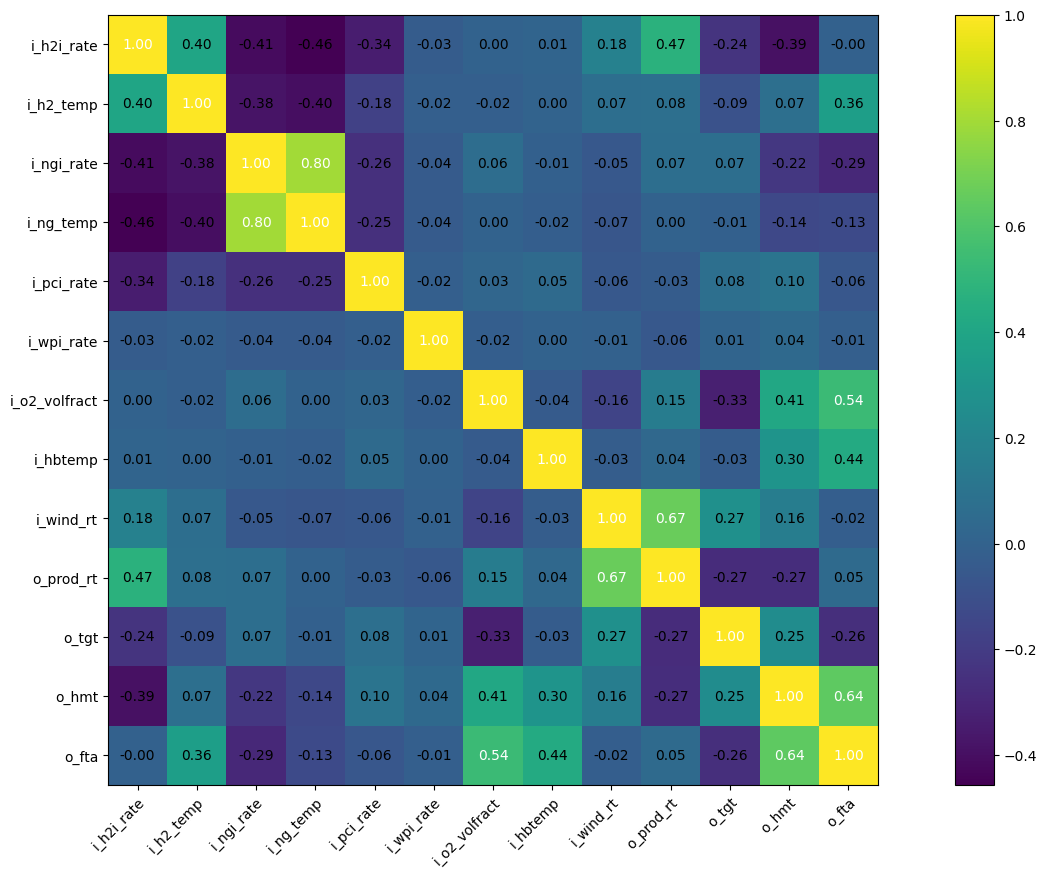

In [13]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta']



PDFshapingOBJ.print_correlation_coefficients()


In [14]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [15]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
4


In [16]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 4)


In [17]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [18]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 4)
(1000, 4)


In [19]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 4)
(1000, 4)


In [20]:

from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca





In [21]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 4)
(1000, 4)
(3999, 4)
(1000, 4)


In [22]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [23]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [24]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [25]:

n_inputs  = 4     ## 7
n_outputs = 4




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [26]:

n_inputs  = 4     ## 7
n_outputs = 4





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [27]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [28]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 1.1631157398223877
100 ..... 0.636785089969635
200 ..... 0.578757107257843
300 ..... 0.5770018100738525
400 ..... 0.5321608185768127
500 ..... 0.5349580645561218
600 ..... 0.5310550332069397
700 ..... 0.674744188785553
800 ..... 0.5893606543540955
900 ..... 0.5110371112823486


In [29]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.5104, 1294.8964, 8443.5146, 2306.9431]])
y_deviations: tensor([[  50.6194,  524.0375, 1513.0557,  211.6117]])
x_means: tensor([[     0.0000,      0.0000,     -0.0000,      0.0000]])
x_deviations: tensor([[275.0049, 157.7931,  50.7492,  35.9717]])


In [30]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  46.8910,  770.8589, 6930.4590, 2095.3315]])
tensor([[ 148.1298, 1818.9338, 9956.5703, 2518.5547]])


In [31]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[-275.0049, -157.7931,  -50.7492,  -35.9717]])
tensor([[275.0049, 157.7931,  50.7492,  35.9717]])



## Is model  invertible ?

* use the Jacobian


In [32]:

import torch
from torch.autograd.functional import jacobian


In [33]:

## x = torch.randn(1, 7, requires_grad=True)

x = torch.randn(      7, requires_grad=True)  # shape [7]

x = torch.randn(      4, requires_grad=True)  # shape [7]


In [34]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  # Only return 1 tensor to get a clean Jacobian




In [35]:

## J = jacobian(model_Forward, x)

J = jacobian(wrapped_model, x)


In [36]:

print( len(J) )


1


In [37]:


print( J.shape )  # Should be [1, 4, 7]


torch.Size([1, 4, 4])


In [38]:

u, s, v = torch.svd(J)  


In [39]:

rank = (s > 1e-5).sum()


In [40]:


print("Local Jacobian rank:", rank.item())


Local Jacobian rank: 4



## Example of Min Norm Solution


In [41]:

import torch
from torch.autograd.functional import jacobian

def solve_minimum_norm_update(x0, target_y):
    """
    Computes a minimum-norm update step for the input x0 towards the target_y.
    
    Args:
        model (nn.Module): The neural network.
        x0 (torch.Tensor): Initial guess for the input.
        target_y (torch.Tensor): The desired output.

    Returns:
        torch.Tensor: The minimum-norm update to x0 (Delta x).
    """
    # Ensure the input requires gradients
    
    x = x0.detach().clone().requires_grad_(True)
    
    # Define a function to compute the output for use with jacobian()
    ## def func(input_x):
    ##    return model(input_x)

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y = target_y - current_y
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    J_pinv = torch.pinverse(J)
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    delta_x = J_pinv @ delta_y
    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x


###################################################################
# Example usage with a simple model (ensure model is defined)
## model = model_Forward()

input_dim  = 4
output_dim = 4

x0       = torch.randn(1, input_dim)

target_y = torch.randn(1, output_dim)
delta_x = solve_minimum_norm_update( x0, target_y)

x_new = x0 + delta_x

print( x_new )



tensor([[-557766.8750, -413991.2500, -136540.9062,  -13695.3867]],
       grad_fn=<AddBackward0>)



## Approach


In [42]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)


In [43]:

def solve_minimum_norm_update2(x0, target_y, tol_update=1e-4, tol_error=1e-3):
    
    # Ensure the input requires gradients
    x = x0.detach().clone().requires_grad_(True)

    # Compute the Jacobian matrix at the current input x
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)

    # Calculate current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y

    # Early stop condition #1: error already small
    if delta_y.norm().item() < tol_error:
        print("Early STOP: small error")
        return torch.zeros_like(x0)

    print(J.shape)

    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)

    # Compute pseudoinverse of the Jacobian using SVD
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > 1e-2, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    # Calculate the minimum norm update
    delta_x = J_pinv @ delta_y
    delta_x = 0.01 * delta_x  # your original scale

    # Early stop condition #2: update too small
    if delta_x.norm().item() < tol_update:
        print("Early STOP: update too small")
        return delta_x.view_as(x0)

    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)

    return delta_x



In [44]:


def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x







In [45]:



x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')



torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.2463967     0.           67.91083112   25.58105575  258.45174727
 1460.00379493  198.79175138]
real
[  10.74006374    0.           65.62454235   25.76152496  299.95295735
 1199.86420784  200.17035547]
1
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.50756581    0.           65.06259055   25.53071434  209.0794927
 1483.85496101  199.0479053 ]
real
[  13.87687605    0.           49.35645526   25.49320886  300.04921482
 1480.04531967  199.71321817]
2
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 

    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  12.4946104     0.           62.22925484   25.57852381  318.25018046
 1442.87691227  199.19722221]
real
[  12.85250477    2.42627464   52.28576223   25.52752734  300.16456789
 1480.24538271  199.16556648]
60
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.0132911     0.           70.15737451   25.5598663   259.88742405
 1516.14641741  198.2521461 ]
real
[  13.59900671    5.89452498   46.92277455   25.43249722  300.05052092
 1600.17382495  198.6527411 ]
61
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   7.81537554    0.           86.72601177   25.64928527  215.82101836
 1518.89007927  196.85151068]
real
[   0.24954711    3.08454454  123.01916023   25.98358289  300.10414802
 1480.18329111  192.67956507]
131
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.86419479    0.           68.78697384   25.51150168  178.44292596
 1531.04504146  198.55813873]
real
[  20.62748671    2.7657225     2.83381687   25.39667552  299.97637872
 1200.02058392  205.21108866]
132
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hb

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.81075779    0.           69.12246202   25.65584358  413.82474821
 1445.05739233  198.25314336]
real
[  11.035081      3.65322098   63.58479606   25.52746699  300.1150386
 1600.20686365  197.34708294]
203
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.60813549    0.           74.03339836   25.61994063  322.84379314
 1497.52977366  197.79978769]
real
[  14.14283388    2.86423363   43.96718867   25.49766418  299.93944876
 1447.98222782  200.06364471]
204
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbt

    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  12.88287458    0.           60.51745697   25.58373314  342.09590954
 1431.892716    199.33300558]
real
[   9.57005715    1.71540263   71.55233702   25.64712066  300.17706403
 1480.24647813  197.48142573]
274
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.56412028    0.           66.33387534   25.54168622  242.97463062
 1495.59290751  198.78890271]
real
[  23.08385556    0.            0.           25.17811358  300.12549231
 1448.10594107  204.69027763]
275
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[

...

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.8801481     0.           67.36725643   25.62584454  364.93394992
 1445.34672884  198.58258741]
real
[   0.            0.          148.95641388   26.31207806  300.01636723
 1199.99879253  192.2887161 ]
707
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  12.39023046    0.           62.91579321   25.58003372  315.07751929
 1444.0884177   199.15492636]
real
[   1.18835322    0.02753577  120.03427908   25.96967536  299.98659649
 1447.9904967   193.4172052 ]
708
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfra

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.65226967    0.           73.74071338   25.62235703  322.75213802
 1490.16307144  197.8774658 ]
real
[  27.85597409    0.            0.           25.49306034 1199.86473276
 1479.81452407  201.48235597]
779
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.74458416    0.           80.5225034    25.72770066  408.11059877
 1444.48493791  197.22826158]
real
[  13.22640064    5.8637442    46.88031209   25.51080689  300.05255829
 1480.1828883   199.33783657]
780
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.54767526    0.           72.59699628   25.55225913  236.71792729
 1537.60648579  197.99647054]
real
[  28.2341726     0.            0.           25.41455947 1199.86155453
 1599.80742996  200.80021826]
851
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.04278938    0.           78.25675772   25.69960662  381.75741641
 1449.35026072  197.50604936]
real
[  21.67423069    0.            0.           25.36159222  299.85657607
 1199.82838603  205.77057232]
852
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hb

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.23034008    0.           76.57393625   25.66536183  350.70178853
 1467.88173092  197.6545022 ]
real
[   0.          200.45545829    0.31757216   26.14564506  300.14026435
 1600.1749737   184.80397444]
924
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.24064567    0.           68.97427904   25.59799073  289.55520809
 1461.46327827  198.59077414]
real
[  24.23294404    0.            0.           25.12204573  300.00455677
 1479.91238197  205.06864662]
925
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.74162879    0.           71.13227062   25.45593881   43.4849338
 1567.96446239  198.52184405]
real
[  14.5481026    43.92268579    3.03311507   25.42815892  299.93745273
 1479.97733783  199.78530353]
986
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   8.69026606    0.           83.59097838   25.61131262  238.79839433
 1555.21244032  196.90047217]
real
[  24.13210706    0.            0.08941537   25.28972952  599.8380849
 1479.79989254  203.17868537]
987
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([

In [48]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 254.91457



## Now add Costs


In [58]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_latent = pca.components_ @ price_real

price_latent = torch.tensor(price_latent, dtype=torch.float32)


In [59]:

def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    ##delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01
    
    lambda_cost = 0.01
    
    delta_x = (J_pinv @ delta_y) - lambda_cost * price_latent
    delta_x = 0.01 * delta_x

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x






In [60]:


x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        # ---- compute cost at this iteration ----
        x_temp_np = x_temp.detach().numpy()
        x_temp_real = pca.inverse_transform(x_temp_np)

        # enforce physical constraint
        x_temp_real = np.maximum(x_temp_real, 0.0)

        cost = np.dot(price_real, x_temp_real)
        
        x_real_np         = x_real.detach().numpy()
        x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
        cost_real         = np.dot(price_real, x_real_np_sol)
       
        print(f"iteration {j} cost: {cost}...H2, PCI, NGI:", x_temp_real[:3] )
        print("real cost       :", cost_real)
        
        
        
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')




torch.Size([1, 4, 4])
iteration 0 cost: 79.0004970438974...H2, PCI, NGI: [10.712458    0.         72.30133007]
real cost       : 71.41337456962044
torch.Size([1, 4, 4])
iteration 1 cost: 78.92911501300534...H2, PCI, NGI: [10.79139033  0.         71.52710742]
real cost       : 71.41337456962044
torch.Size([1, 4, 4])
iteration 2 cost: 78.81931160166609...H2, PCI, NGI: [10.84390324  0.         70.88739732]
real cost       : 71.41337456962044
torch.Size([1, 4, 4])
iteration 3 cost: 78.86356278320599...H2, PCI, NGI: [11.03556155  0.         69.44263316]
real cost       : 71.41337456962044
torch.Size([1, 4, 4])
iteration 4 cost: 78.87101675673142...H2, PCI, NGI: [11.207199    0.         68.08444154]
real cost       : 71.41337456962044
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.207199      0.           68.08444154   25.57977142  255.54153612
 1461.994797    198.77463457]
real
[  10.74006374    0.           65.62454235   2

iteration 4 cost: 82.35196788938225...H2, PCI, NGI: [12.2567982   0.         66.64955018]
real cost       : 75.37953936547886
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  12.2567982     0.           66.64955018   25.64516074  418.95267281
 1440.21336724  198.48691885]
real
[   7.74704044    2.95672295   82.86930927   25.6472515   300.12864515
 1600.20599376  195.65998434]
53
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 79.23422514463738...H2, PCI, NGI: [10.68348887  0.         73.0005393 ]
real cost       : 101.31975578990188
torch.Size([1, 4, 4])
iteration 1 cost: 79.56008974335651...H2, PCI, NGI: [10.88556567  0.         72.03565409]
real cost       : 101.31975578990188
torch.Size([1, 4, 4])
iteration 2 cost: 79.83741913647032...H2, PCI, NGI: [11.05209495  0.         71.25807868]
real cost       : 101.31975578990188
torch.Size([1, 4, 4])
iteration 3 cost: 80.17019879721008...H2, PCI, NGI: [

iteration 0 cost: 78.98484297712372...H2, PCI, NGI: [10.67091887  0.         72.60233501]
real cost       : 75.31652577543579
torch.Size([1, 4, 4])
iteration 1 cost: 78.9938176394274...H2, PCI, NGI: [10.80518598  0.         71.54614741]
real cost       : 75.31652577543579
torch.Size([1, 4, 4])
iteration 2 cost: 78.91505462124988...H2, PCI, NGI: [10.88202955  0.         70.77387284]
real cost       : 75.31652577543579
torch.Size([1, 4, 4])
iteration 3 cost: 79.00178774311246...H2, PCI, NGI: [11.09906187  0.         69.21108051]
real cost       : 75.31652577543579
torch.Size([1, 4, 4])
iteration 4 cost: 79.1343034908149...H2, PCI, NGI: [11.35645949  0.         67.4169311 ]
real cost       : 75.31652577543579
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.35645949    0.           67.4169311    25.56924879  258.17532113
 1473.992615    198.74708808]
real
[   9.39447165    1.80471717   71.86784398   25.67069207  299.9553486

torch.Size([1, 4, 4])
iteration 1 cost: 78.47551374612519...H2, PCI, NGI: [10.51290726  0.         72.84776941]
real cost       : 90.4208037468504
torch.Size([1, 4, 4])
iteration 2 cost: 78.36728540446613...H2, PCI, NGI: [10.60718101  0.         71.87712271]
real cost       : 90.4208037468504
torch.Size([1, 4, 4])
iteration 3 cost: 78.1532453414288...H2, PCI, NGI: [10.61150408  0.         71.41445801]
real cost       : 90.4208037468504
torch.Size([1, 4, 4])
iteration 4 cost: 77.91548761920473...H2, PCI, NGI: [10.60660892  0.         70.97810387]
real cost       : 90.4208037468504
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.60660892    0.           70.97810387   25.54989779  207.77786709
 1508.16664831  198.41737123]
real
[   0.           56.0121344    86.07424716   26.02247658  299.88597073
 1479.7884388   191.11957709]
171
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 79.39519918644774...

iteration 1 cost: 78.52986432368873...H2, PCI, NGI: [10.30376581  0.         74.62960219]
real cost       : 148.23095431558568
torch.Size([1, 4, 4])
iteration 2 cost: 78.3455691532933...H2, PCI, NGI: [10.20928951  0.         75.01682225]
real cost       : 148.23095431558568
torch.Size([1, 4, 4])
iteration 3 cost: 78.18912280707009...H2, PCI, NGI: [10.13777926  0.         75.27601151]
real cost       : 148.23095431558568
torch.Size([1, 4, 4])
iteration 4 cost: 77.98917320720356...H2, PCI, NGI: [10.03538689  0.         75.69525133]
real cost       : 148.23095431558568
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.03538689    0.           75.69525133   25.63139792  283.56712092
 1473.98509257  197.91450965]
real
[   0.          173.26103779    0.           25.99096369  300.00715214
 1599.98038882  187.52315704]
230
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 78.77289942157515...H2, PCI, NGI: 

...

torch.Size([1, 4, 4])
iteration 2 cost: 79.76570157391109...H2, PCI, NGI: [10.79607862  0.         73.1627742 ]
real cost       : 81.1391553814166
torch.Size([1, 4, 4])
iteration 3 cost: 80.06505779622213...H2, PCI, NGI: [10.90854099  0.         72.86178765]
real cost       : 81.1391553814166
torch.Size([1, 4, 4])
iteration 4 cost: 80.07788821854025...H2, PCI, NGI: [10.81141938  0.         73.66442137]
real cost       : 81.1391553814166
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.81141938    0.           73.66442137   25.64766602  360.28235659
 1471.65763996  197.86812408]
real
[  14.26066875    0.           49.36303925   25.41451676  300.04496414
 1600.04020222  199.03403866]
725
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 78.5639400217303...H2, PCI, NGI: [10.38367642  0.         74.05846867]
real cost       : 74.93601295366383
torch.Size([1, 4, 4])
iteration 1 cost: 78.55816767354791..

iteration 2 cost: 78.67820289608616...H2, PCI, NGI: [ 9.63950267  0.         80.24038442]
real cost       : 114.10707546581307
torch.Size([1, 4, 4])
iteration 3 cost: 78.98041923720874...H2, PCI, NGI: [ 9.68261326  0.         80.49993241]
real cost       : 114.10707546581307
torch.Size([1, 4, 4])
iteration 4 cost: 78.01975597978289...H2, PCI, NGI: [ 8.71856088  0.         86.2910249 ]
real cost       : 114.10707546581307
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   8.71856088    0.           86.2910249    25.73719483  387.84509617
 1474.73593496  196.60197463]
real
[  11.43730963   68.85390153    0.           25.45333908  299.83012676
 1599.78051214  197.15692569]
784
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 79.10754719151646...H2, PCI, NGI: [10.70764987  0.         72.55389543]
real cost       : 91.31766995642062
torch.Size([1, 4, 4])
iteration 1 cost: 79.23767720821448...H2, PCI, NGI: 

iteration 3 cost: 81.48563655693033...H2, PCI, NGI: [12.95263269  0.         59.35021156]
real cost       : 92.0371350888496
torch.Size([1, 4, 4])
iteration 4 cost: 81.74165903838372...H2, PCI, NGI: [13.21976707  0.         57.72518155]
real cost       : 92.0371350888496
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  13.21976707    0.           57.72518155   25.56045678  322.80245816
 1431.81133381  199.62143112]
real
[  21.44800904    4.19111388    4.1079701    25.14966075  300.12795116
 1600.23948438  202.6996966 ]
841
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 78.6667851622327...H2, PCI, NGI: [10.27515533  0.         75.13232766]
real cost       : 132.164118900399
torch.Size([1, 4, 4])
iteration 1 cost: 78.34752611287618...H2, PCI, NGI: [10.00338225  0.         76.66799425]
real cost       : 132.164118900399
torch.Size([1, 4, 4])
iteration 2 cost: 78.06968147684296...H2, PCI, NGI: [ 9.7582

torch.Size([1, 4, 4])
iteration 4 cost: 82.69916482949347...H2, PCI, NGI: [10.86855493  0.         78.44989024]
real cost       : 71.51994913381009
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.86855493    0.           78.44989024   25.82068087  582.95561267
 1378.9047029   197.23125398]
real
[   6.21436874    1.09438707   91.13617417   25.76930083  299.96671178
 1479.98748471  195.76230152]
897
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 78.78957977890188...H2, PCI, NGI: [10.56112149  0.         73.09018761]
real cost       : 81.41819192303922
torch.Size([1, 4, 4])
iteration 1 cost: 78.67771198709656...H2, PCI, NGI: [10.66170198  0.         72.06180813]
real cost       : 81.41819192303922
torch.Size([1, 4, 4])
iteration 2 cost: 78.8335366717568...H2, PCI, NGI: [10.95602895  0.         70.01884172]
real cost       : 81.41819192303922
torch.Size([1, 4, 4])
iteration 3 cost: 78.5331711228360

torch.Size([1, 4, 4])
iteration 3 cost: 76.87903100903313...H2, PCI, NGI: [ 9.90664816  0.         74.5048767 ]
real cost       : 78.21541119673758
torch.Size([1, 4, 4])
iteration 4 cost: 76.43213671404945...H2, PCI, NGI: [ 9.80927468  0.         74.39007599]
real cost       : 78.21541119673758
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.80927468    0.           74.39007599   25.54099654  169.21815587
 1537.26334106  198.02444635]
real
[  10.09129595    5.23153993   65.23737495   25.62499416  300.06776257
 1480.17803182  197.72902894]
955
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 78.3962982548272...H2, PCI, NGI: [10.3202557   0.         74.23055087]
real cost       : 86.30915049924903
torch.Size([1, 4, 4])
iteration 1 cost: 77.82736016110762...H2, PCI, NGI: [10.115626   0.        74.7297123]
real cost       : 86.30915049924903
torch.Size([1, 4, 4])
iteration 2 cost: 77.80567936169808..

In [61]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 254.83942
